In [1]:
"""
Reproduction of Fig. 3c of Hymas et al., "Superextensive electrical power from a
quantum battery", Light: Science & Applications 15, 168 (2026)
-------------------------------------------------------------------------------
Version 2: QuTiP (mesolve) solution of the Lindblad master equation.

Model (main text Eqs. (3)-(4), SI Sec. III E):
  Driven Tavis-Cummings Hamiltonian, in the rotating frame of the laser, for
  N four-level CuPc molecules {S0=|0>, S1^0=|1>, S1^1=|2>, T1=|T>} coupled to
  one cavity mode, with Lindblad dissipators for cavity loss (kappa), singlet
  non-radiative decay (gamma^-), triplet decay (gamma_T^-), singlet dephasing
  (gamma^z), and intersystem crossing (gamma_ISC).

How the N ~ 5e10 ensemble is made tractable for an exact solver
---------------------------------------------------------------
The exact Hilbert space of Eq. (3) is unreachable for any numerically exact
solver (the authors close a cumulant hierarchy with O(1/N) errors, SI Eq.
(11)).  We therefore use the standard, controlled large-N / weak-excitation
(Holstein-Primakoff) reduction of the driven Tavis-Cummings model.  Fig. 3c
involves per-molecule populations <= 0.08, so corrections to this reduction
are at the few-percent level and vanish in the same N -> infinity limit as
the paper's cumulant closure.

  * The BRIGHT collective transitions B_k = N^{-1/2} sum_j X_{0k}^{(j)}
    (k = 1, 2 for the two Davydov singlets) become bosonic modes b1, b2 that
    carry the full collective coupling G = g*sqrt(N):

      H = (Dc-nu) a^+a + (D1-nu) b1^+b1 + (D2-nu) b2^+b2
          + G [ a^+ (b1 + b2) + (b1^+ + b2^+) a ]  +  i eta_s(t) (a^+ - a).

  * Single-molecule DEPHASING gamma^z (Lindblads L[X11], L[X22] in Eq. (4))
    does two things to the ensemble: it damps the collective optical
    coherence at gamma^z/2, and it scatters excitation out of the bright
    superposition into the N-1 cavity-DECOUPLED dark states at rate gamma^z
    (the dark -> bright return rate is gamma^z/N -> 0).  Both effects are
    captured exactly by the incoherent bright -> dark transfer dissipators
    gamma^z L[d1^+ b1] and gamma^z L[d2^+ b2], where d1, d2 are dark
    reservoir modes.  (Modelling dephasing as pure dephasing L[b^+b] of the
    single bright mode would wrongly keep dephased excitons coupled to the
    leaky cavity; the dark-state protection against superradiant decay is
    essential to the triplet yield, as emphasised in the paper's Discussion.)

  * Intersystem crossing gamma_ISC transfers bright AND dark singlet
    excitation to the triplet reservoir T: dissipators L[T^+ b_k], L[T^+ d_k].
    Singlet decay gamma^- acts on bright and dark modes alike; triplet decay
    gamma_T^- acts on T.

  * Rescaling the drive, eta_s(t) = eta(t)/sqrt(N)
    = sqrt(r/(2 pi sigma^2)) exp(-(t-t0)^2/(2 sigma^2)), makes every mode
    occupation an occupation PER MOLECULE, so that
       <X11> = <b1^+b1> + <d1^+d1>   (S1^0, yellow curve of Fig. 3c)
       <X22> = <b2^+b2> + <d2^+d2>   (S1^1, blue curve)
       <XTT> = <T^+T>                (T1,   purple curve).
    For the linearly driven weak-excitation model this rescaling is exact.

  * Exact gauge choices: the dark and triplet reservoirs enter H only through
    number operators and enter the dissipators only through jump operators,
    which acquire a pure phase under d -> d e^{-i w t}; every Lindblad
    dissipator D[L] is invariant under L -> e^{i phi} L, so their level
    energies (including DT = 1.2 eV) can be set to zero without changing any
    population.  This removes irrelevant THz-scale phase evolution and makes
    the integration fast.  Occupations stay < 0.1 per molecule, so the dark
    and triplet reservoirs are truncated to two levels and the bright/cavity
    modes to small Fock cutoffs.

Parameters: device D5 (SI Tables S1 and S3, main text):
  D1 = 1.80 eV, D2 = 1.98 eV, DT = 1.20 eV, Dc = 1.82 eV,
  g = 500 neV (ultrafast spot), N = 5.0e10  ->  G = g*sqrt(N) ~ 111.8 meV,
  kappa = 29 ps^-1, gamma^- = 0.5 ps^-1, gamma_T^- = 0.01 ps^-1,
  gamma^z = 20 ps^-1, gamma_ISC = 5 ps^-1 (= 1/200 fs),
  Gaussian pulse: sigma = 35/(2 sqrt(2 ln 2)) fs, r = 1/2,
  laser frequency nu tuned to the lower polariton of the device.
"""

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# ----------------------------- physical constants ---------------------------
hbar = 6.582119569e-4          # eV * ps

# ------------------------- device D5 parameters -----------------------------
Delta1, Delta2, DeltaT, Deltac = 1.80, 1.98, 1.20, 1.82   # eV
g_bare = 500e-9                # eV   [Table S3, ultrafast spot]
N      = 5.0e10                # D5   [Table S3]
G      = g_bare * np.sqrt(N)   # collective coupling (eV)

kappa, gamma_m, gamma_T = 29.0, 0.5, 0.01     # ps^-1  [Table S3, D5]
gamma_z, gamma_ISC      = 20.0, 5.0           # ps^-1

r     = 0.5
sigma = (35.0 / (2*np.sqrt(2*np.log(2)))) * 1e-3   # ps
t0    = 0.10                                       # ps

# ------------- laser tuned to the lower polariton of the device -------------
M_pol = np.array([[Deltac, G,      G     ],
                  [G,      Delta1, 0.0   ],
                  [G,      0.0,    Delta2]])
nu = np.linalg.eigvalsh(M_pol)[0]

# detunings as angular frequencies (rad/ps)
d1, d2, dc = (Delta1-nu)/hbar, (Delta2-nu)/hbar, (Deltac-nu)/hbar
Gw = G / hbar


def build_model(use_kappa=1, use_gamma_m=1, use_gamma_T=1, use_gamma_z=1, use_gamma_ISC=1):
    """Operators, Hamiltonian, collapse and measurement operators."""
    Na, Nb = 5, 3              # cavity / bright-exciton Fock cutoffs
    Ia, Ib, I2 = qt.qeye(Na), qt.qeye(Nb), qt.qeye(2)

    def emb(op, slot):
        ops = [Ia, Ib, Ib, I2, I2, I2]     # a, b1, b2, d1, d2, T
        ops[slot] = op
        return qt.tensor(*ops)

    a  = emb(qt.destroy(Na), 0)            # cavity mode
    b1 = emb(qt.destroy(Nb), 1)            # bright S1^0 exciton
    b2 = emb(qt.destroy(Nb), 2)            # bright S1^1 exciton
    dk1 = emb(qt.destroy(2), 3)            # dark S1^0 reservoir (2-level)
    dk2 = emb(qt.destroy(2), 4)            # dark S1^1 reservoir
    Tm  = emb(qt.destroy(2), 5)            # triplet reservoir (2-level)

    H0 = (dc * a.dag()*a + d1 * b1.dag()*b1 + d2 * b2.dag()*b2
          + Gw * (a.dag()*(b1 + b2) + (b1.dag() + b2.dag())*a))
    Hdrive = 1j * (a.dag() - a)            # i eta_s(t) (a^+ - a)

    c_ops = []
    if use_kappa: c_ops.append(np.sqrt(kappa) * a)
    if use_gamma_m:
        c_ops.extend([np.sqrt(gamma_m) * b1, np.sqrt(gamma_m) * b2, np.sqrt(gamma_m) * dk1, np.sqrt(gamma_m) * dk2])
    if use_gamma_T: c_ops.append(np.sqrt(gamma_T) * Tm)
    if use_gamma_z:
        c_ops.extend([np.sqrt(gamma_z) * dk1.dag()*b1, np.sqrt(gamma_z) * dk2.dag()*b2])
    if use_gamma_ISC:
        c_ops.extend([np.sqrt(gamma_ISC) * Tm.dag()*b1, np.sqrt(gamma_ISC) * Tm.dag()*b2, np.sqrt(gamma_ISC) * Tm.dag()*dk1, np.sqrt(gamma_ISC) * Tm.dag()*dk2])

    e_ops = [b1.dag()*b1 + dk1.dag()*dk1,           # <X11>  (S1^0)
             b2.dag()*b2 + dk2.dag()*dk2,           # <X22>  (S1^1)
             Tm.dag()*Tm,                           # <XTT>  (T1)
             a.dag()*a]                             # photons per molecule

    psi0 = qt.tensor(qt.basis(Na, 0), qt.basis(Nb, 0), qt.basis(Nb, 0),
                     qt.basis(2, 0), qt.basis(2, 0), qt.basis(2, 0))
    return H0, Hdrive, c_ops, e_ops, psi0


def eta_s(t):
    """Rescaled pulse envelope eta(t)/sqrt(N) (rad/ps)."""
    return np.sqrt(r / (2*np.pi*sigma**2)) * np.exp(-(t - t0)**2 / (2*sigma**2))

print(f"laser nu = {nu:.4f} eV (lower polariton),  G = {G*1e3:.1f} meV")


laser nu = 1.6771 eV (lower polariton),  G = 111.8 meV


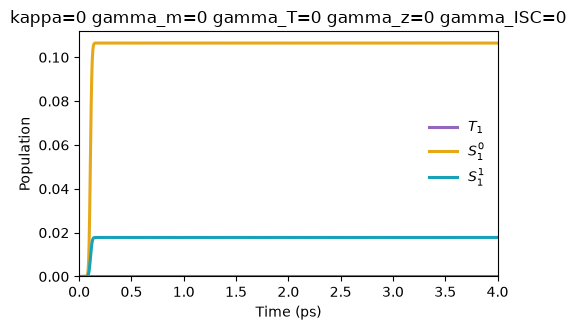

In [5]:
# Condition: kappa=0, gamma_m=0, gamma_T=0, gamma_z=0, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=0, use_gamma_T=0, use_gamma_z=0, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=0 gamma_T=0 gamma_z=0 gamma_ISC=0")
plt.tight_layout()
plt.show()


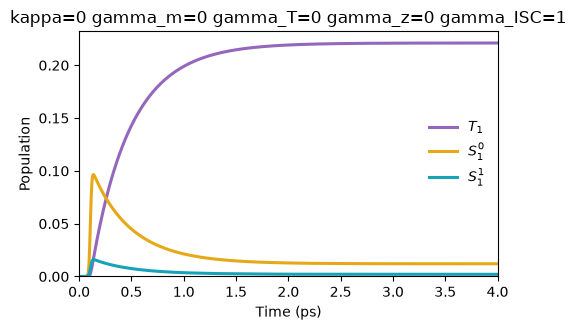

In [6]:
# Condition: kappa=0, gamma_m=0, gamma_T=0, gamma_z=0, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=0, use_gamma_T=0, use_gamma_z=0, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=0 gamma_T=0 gamma_z=0 gamma_ISC=1")
plt.tight_layout()
plt.show()


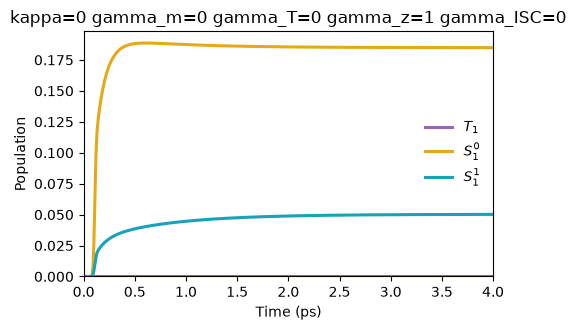

In [7]:
# Condition: kappa=0, gamma_m=0, gamma_T=0, gamma_z=1, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=0, use_gamma_T=0, use_gamma_z=1, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=0 gamma_T=0 gamma_z=1 gamma_ISC=0")
plt.tight_layout()
plt.show()


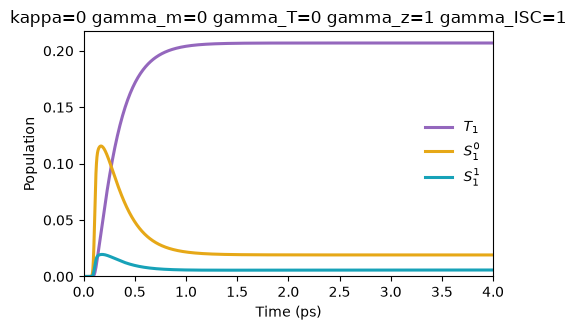

In [8]:
# Condition: kappa=0, gamma_m=0, gamma_T=0, gamma_z=1, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=0, use_gamma_T=0, use_gamma_z=1, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=0 gamma_T=0 gamma_z=1 gamma_ISC=1")
plt.tight_layout()
plt.show()


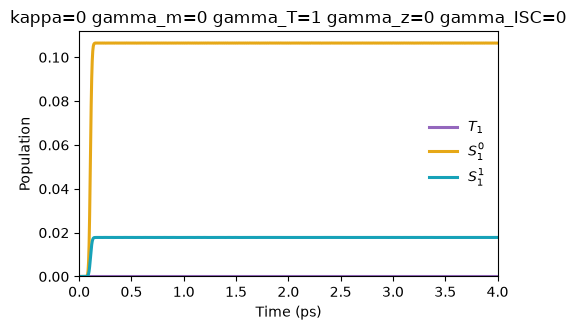

In [9]:
# Condition: kappa=0, gamma_m=0, gamma_T=1, gamma_z=0, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=0, use_gamma_T=1, use_gamma_z=0, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=0 gamma_T=1 gamma_z=0 gamma_ISC=0")
plt.tight_layout()
plt.show()


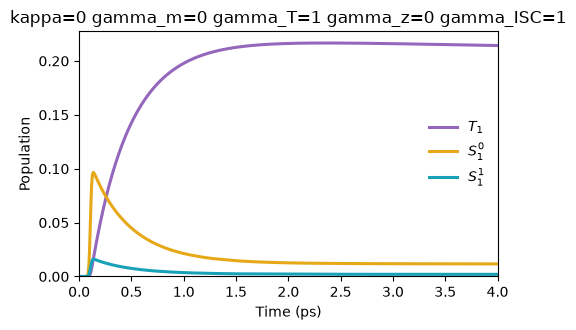

In [10]:
# Condition: kappa=0, gamma_m=0, gamma_T=1, gamma_z=0, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=0, use_gamma_T=1, use_gamma_z=0, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=0 gamma_T=1 gamma_z=0 gamma_ISC=1")
plt.tight_layout()
plt.show()


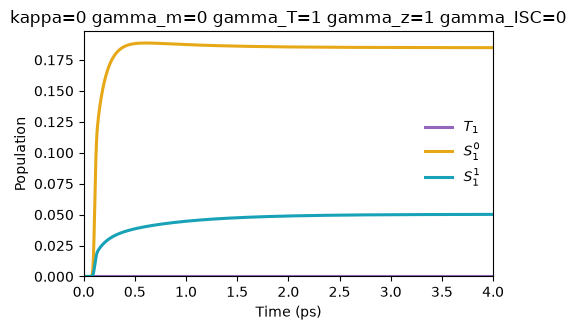

In [11]:
# Condition: kappa=0, gamma_m=0, gamma_T=1, gamma_z=1, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=0, use_gamma_T=1, use_gamma_z=1, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=0 gamma_T=1 gamma_z=1 gamma_ISC=0")
plt.tight_layout()
plt.show()


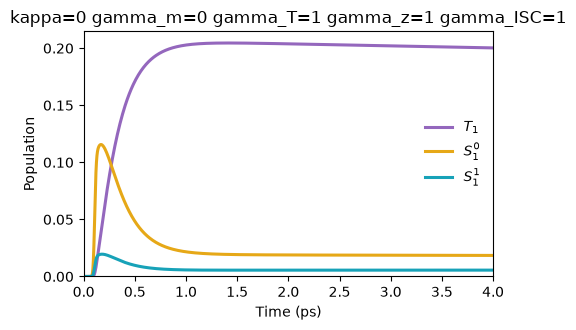

In [12]:
# Condition: kappa=0, gamma_m=0, gamma_T=1, gamma_z=1, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=0, use_gamma_T=1, use_gamma_z=1, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=0 gamma_T=1 gamma_z=1 gamma_ISC=1")
plt.tight_layout()
plt.show()


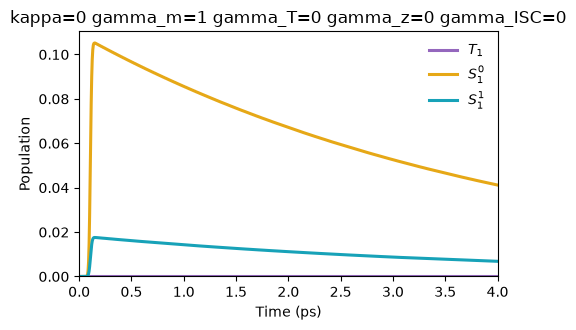

In [13]:
# Condition: kappa=0, gamma_m=1, gamma_T=0, gamma_z=0, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=1, use_gamma_T=0, use_gamma_z=0, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=1 gamma_T=0 gamma_z=0 gamma_ISC=0")
plt.tight_layout()
plt.show()


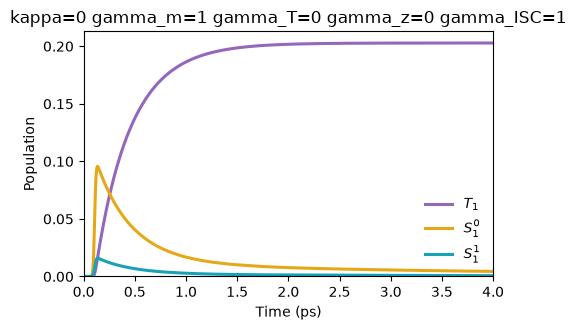

In [14]:
# Condition: kappa=0, gamma_m=1, gamma_T=0, gamma_z=0, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=1, use_gamma_T=0, use_gamma_z=0, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=1 gamma_T=0 gamma_z=0 gamma_ISC=1")
plt.tight_layout()
plt.show()


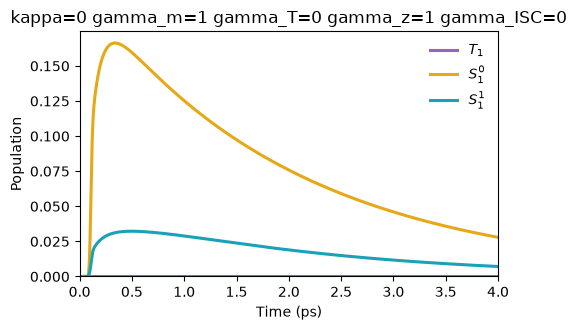

In [15]:
# Condition: kappa=0, gamma_m=1, gamma_T=0, gamma_z=1, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=1, use_gamma_T=0, use_gamma_z=1, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=1 gamma_T=0 gamma_z=1 gamma_ISC=0")
plt.tight_layout()
plt.show()


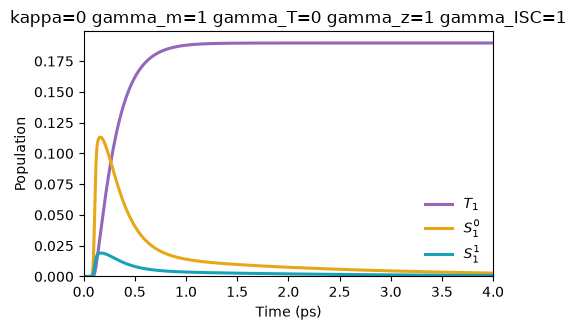

In [16]:
# Condition: kappa=0, gamma_m=1, gamma_T=0, gamma_z=1, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=1, use_gamma_T=0, use_gamma_z=1, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=1 gamma_T=0 gamma_z=1 gamma_ISC=1")
plt.tight_layout()
plt.show()


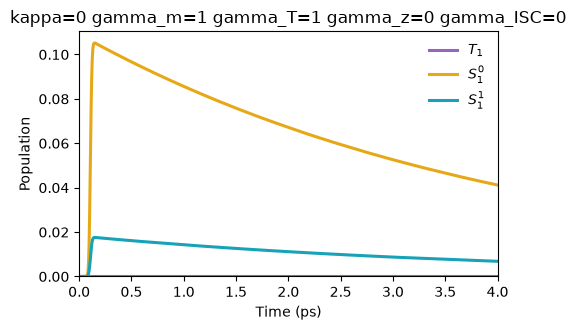

In [17]:
# Condition: kappa=0, gamma_m=1, gamma_T=1, gamma_z=0, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=1, use_gamma_T=1, use_gamma_z=0, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=1 gamma_T=1 gamma_z=0 gamma_ISC=0")
plt.tight_layout()
plt.show()


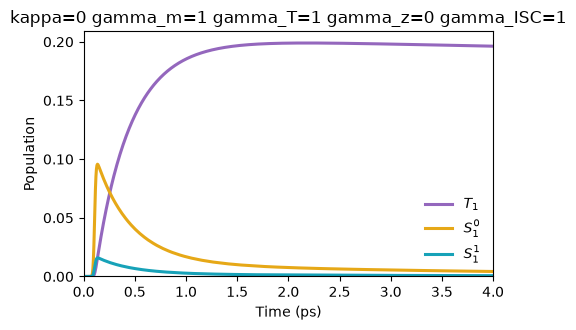

In [18]:
# Condition: kappa=0, gamma_m=1, gamma_T=1, gamma_z=0, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=1, use_gamma_T=1, use_gamma_z=0, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=1 gamma_T=1 gamma_z=0 gamma_ISC=1")
plt.tight_layout()
plt.show()


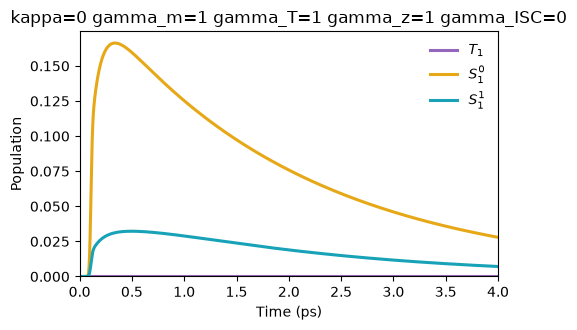

In [19]:
# Condition: kappa=0, gamma_m=1, gamma_T=1, gamma_z=1, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=1, use_gamma_T=1, use_gamma_z=1, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=1 gamma_T=1 gamma_z=1 gamma_ISC=0")
plt.tight_layout()
plt.show()


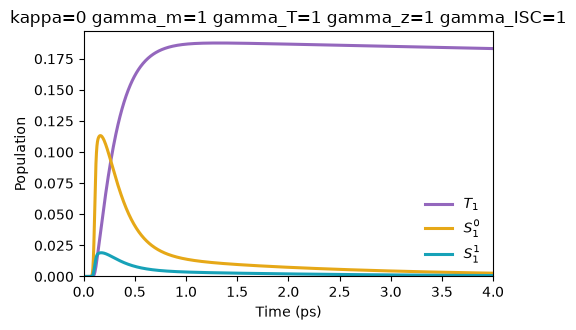

In [2]:
# Condition: kappa=0, gamma_m=1, gamma_T=1, gamma_z=1, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=0, use_gamma_m=1, use_gamma_T=1, use_gamma_z=1, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=0 gamma_m=1 gamma_T=1 gamma_z=1 gamma_ISC=1")
plt.tight_layout()
plt.show()


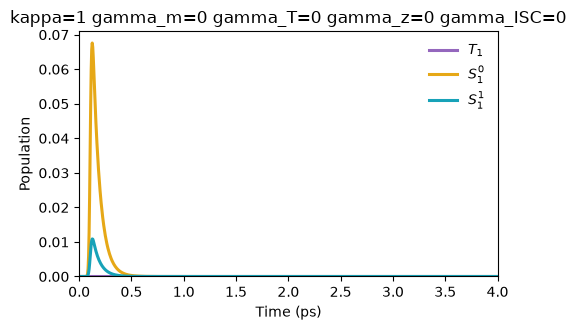

In [18]:
# Condition: kappa=1, gamma_m=0, gamma_T=0, gamma_z=0, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=0, use_gamma_T=0, use_gamma_z=0, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=0 gamma_T=0 gamma_z=0 gamma_ISC=0")
plt.tight_layout()
plt.show()


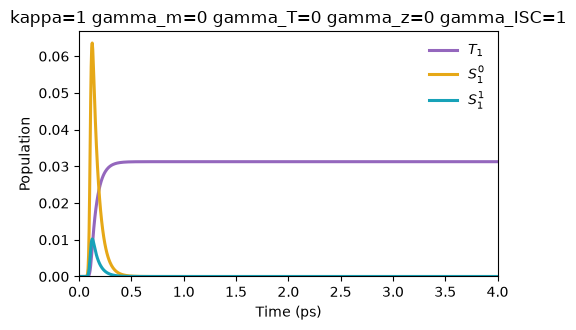

In [3]:
# Condition: kappa=1, gamma_m=0, gamma_T=0, gamma_z=0, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=0, use_gamma_T=0, use_gamma_z=0, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=0 gamma_T=0 gamma_z=0 gamma_ISC=1")
plt.tight_layout()
plt.show()


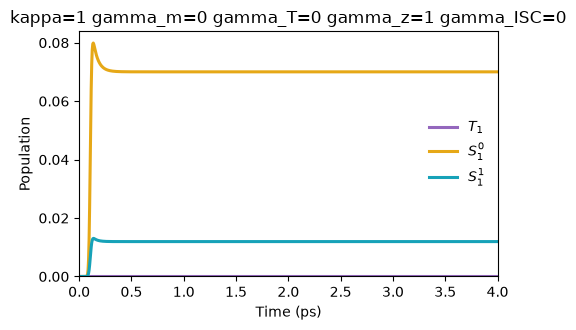

In [4]:
# Condition: kappa=1, gamma_m=0, gamma_T=0, gamma_z=1, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=0, use_gamma_T=0, use_gamma_z=1, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=0 gamma_T=0 gamma_z=1 gamma_ISC=0")
plt.tight_layout()
plt.show()


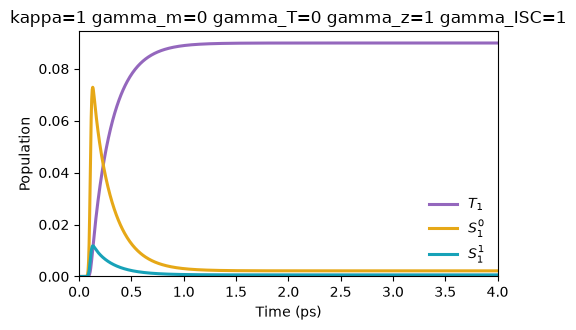

In [5]:
# Condition: kappa=1, gamma_m=0, gamma_T=0, gamma_z=1, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=0, use_gamma_T=0, use_gamma_z=1, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=0 gamma_T=0 gamma_z=1 gamma_ISC=1")
plt.tight_layout()
plt.show()


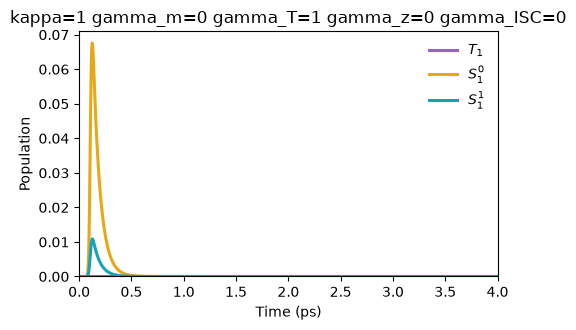

In [6]:
# Condition: kappa=1, gamma_m=0, gamma_T=1, gamma_z=0, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=0, use_gamma_T=1, use_gamma_z=0, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=0 gamma_T=1 gamma_z=0 gamma_ISC=0")
plt.tight_layout()
plt.show()


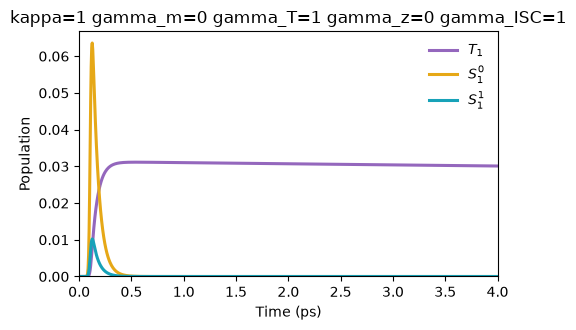

In [7]:
# Condition: kappa=1, gamma_m=0, gamma_T=1, gamma_z=0, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=0, use_gamma_T=1, use_gamma_z=0, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=0 gamma_T=1 gamma_z=0 gamma_ISC=1")
plt.tight_layout()
plt.show()


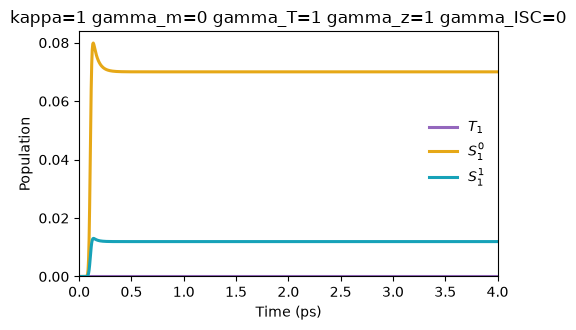

In [8]:
# Condition: kappa=1, gamma_m=0, gamma_T=1, gamma_z=1, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=0, use_gamma_T=1, use_gamma_z=1, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=0 gamma_T=1 gamma_z=1 gamma_ISC=0")
plt.tight_layout()
plt.show()


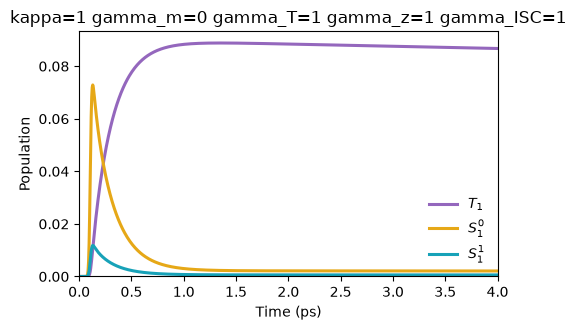

In [9]:
# Condition: kappa=1, gamma_m=0, gamma_T=1, gamma_z=1, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=0, use_gamma_T=1, use_gamma_z=1, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=0 gamma_T=1 gamma_z=1 gamma_ISC=1")
plt.tight_layout()
plt.show()


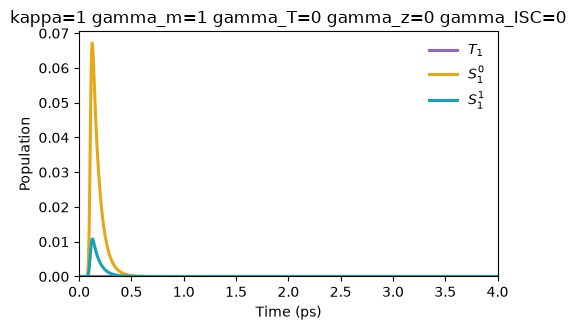

In [10]:
# Condition: kappa=1, gamma_m=1, gamma_T=0, gamma_z=0, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=1, use_gamma_T=0, use_gamma_z=0, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=1 gamma_T=0 gamma_z=0 gamma_ISC=0")
plt.tight_layout()
plt.show()


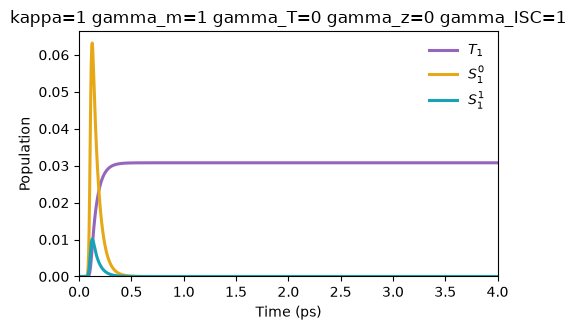

In [11]:
# Condition: kappa=1, gamma_m=1, gamma_T=0, gamma_z=0, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=1, use_gamma_T=0, use_gamma_z=0, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=1 gamma_T=0 gamma_z=0 gamma_ISC=1")
plt.tight_layout()
plt.show()


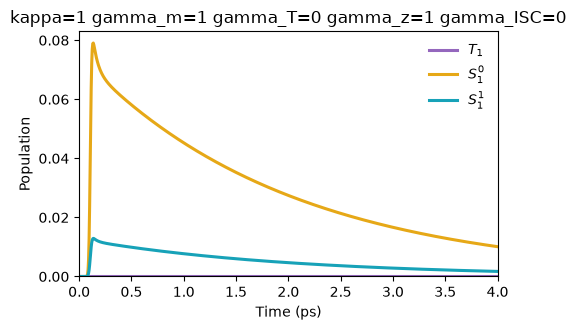

In [12]:
# Condition: kappa=1, gamma_m=1, gamma_T=0, gamma_z=1, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=1, use_gamma_T=0, use_gamma_z=1, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=1 gamma_T=0 gamma_z=1 gamma_ISC=0")
plt.tight_layout()
plt.show()


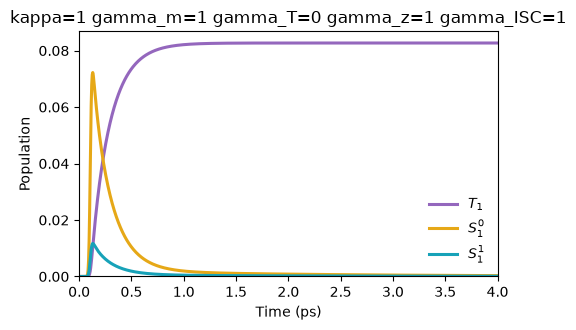

In [13]:
# Condition: kappa=1, gamma_m=1, gamma_T=0, gamma_z=1, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=1, use_gamma_T=0, use_gamma_z=1, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=1 gamma_T=0 gamma_z=1 gamma_ISC=1")
plt.tight_layout()
plt.show()


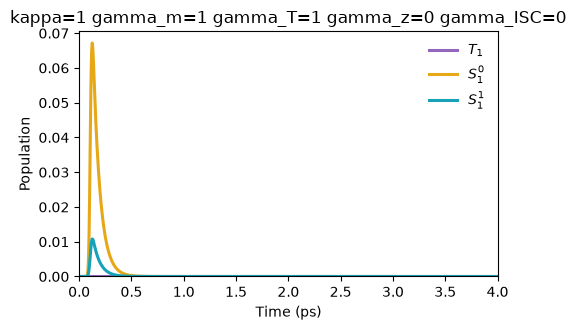

In [14]:
# Condition: kappa=1, gamma_m=1, gamma_T=1, gamma_z=0, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=1, use_gamma_T=1, use_gamma_z=0, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=1 gamma_T=1 gamma_z=0 gamma_ISC=0")
plt.tight_layout()
plt.show()


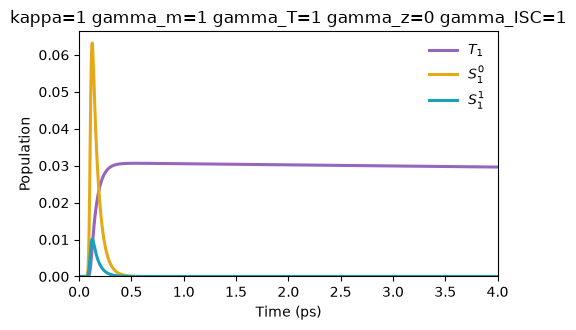

In [15]:
# Condition: kappa=1, gamma_m=1, gamma_T=1, gamma_z=0, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=1, use_gamma_T=1, use_gamma_z=0, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=1 gamma_T=1 gamma_z=0 gamma_ISC=1")
plt.tight_layout()
plt.show()


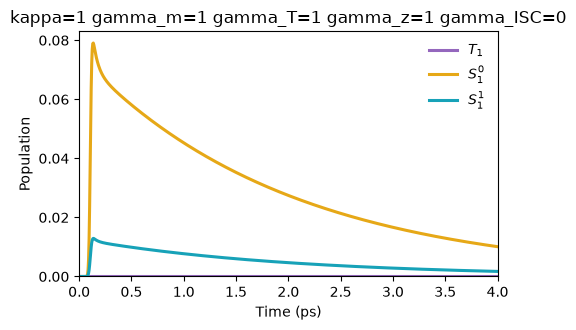

In [16]:
# Condition: kappa=1, gamma_m=1, gamma_T=1, gamma_z=1, gamma_ISC=0
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=1, use_gamma_T=1, use_gamma_z=1, use_gamma_ISC=0)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=1 gamma_T=1 gamma_z=1 gamma_ISC=0")
plt.tight_layout()
plt.show()


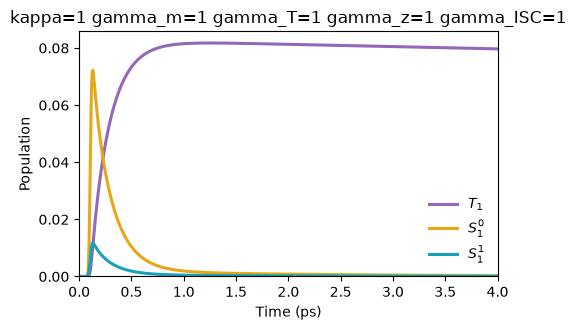

In [17]:
# Condition: kappa=1, gamma_m=1, gamma_T=1, gamma_z=1, gamma_ISC=1
H0, Hdrive, c_ops, e_ops, psi0 = build_model(use_kappa=1, use_gamma_m=1, use_gamma_T=1, use_gamma_z=1, use_gamma_ISC=1)
H = [H0, [Hdrive, eta_s]]

tlist = np.linspace(0.0, 4.0, 801)     # ps
res = qt.mesolve(H, psi0, tlist, c_ops, e_ops=e_ops,
                    options={"atol": 1e-9, "rtol": 1e-7, "nsteps": 1000000})

P_S10, P_S11, P_T1, n_ph = (np.real(res.expect[k]) for k in range(4))

plt.figure(figsize=(5.2, 3.4))
plt.plot(tlist, P_T1,  color="#9467bd", lw=2.2, label=r"$T_1$")
plt.plot(tlist, P_S10, color="#e6a817", lw=2.2, label=r"$S_1^0$")
plt.plot(tlist, P_S11, color="#17a2b8", lw=2.2, label=r"$S_1^1$")
plt.xlabel("Time (ps)")
plt.ylabel("Population")
plt.xlim(0, 4)
plt.ylim(bottom=0)
plt.legend(frameon=False)
plt.title(f"kappa=1 gamma_m=1 gamma_T=1 gamma_z=1 gamma_ISC=1")
plt.tight_layout()
plt.show()
